# IEEE 123 Node

In [1]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix

from unit_converter import UnitConverter
import fault
import fault1
import fault2
import locator
import locator1
import locator1_2

import locator2
import locator3
from topologia import FeederTopology
from funcoes_plot import plot_erro

In [2]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('C:/Users/grei-luis-felipe/Documents/fault-location/tcc-luis-felipe')

In [3]:
DSS_FILE_REG_NEUTRAL = BASE_DIR / "data" / "123Bus" / "Run_IEEE123Bus_reg_neutral_tap.dss"
DSS_FILE_REG_SET = BASE_DIR / "data" / "123Bus" / "Run_IEEE123Bus_tap_setted.dss"
DSS_FILE_NO_REG = BASE_DIR / "data" / "123Bus" / "Run_IEEE123Bus_no_reg.dss"


## Medida SE, com regulador tap neutro

In [4]:
simulador = fault.FaultSimulator(str(DSS_FILE_REG_NEUTRAL), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.5
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_REG_NEUTRAL), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df1 = localizador.df.copy()

Aplicando Filtro MI: 100%|██████████| 2001/2001 [00:00<00:00, 7695.12it/s]


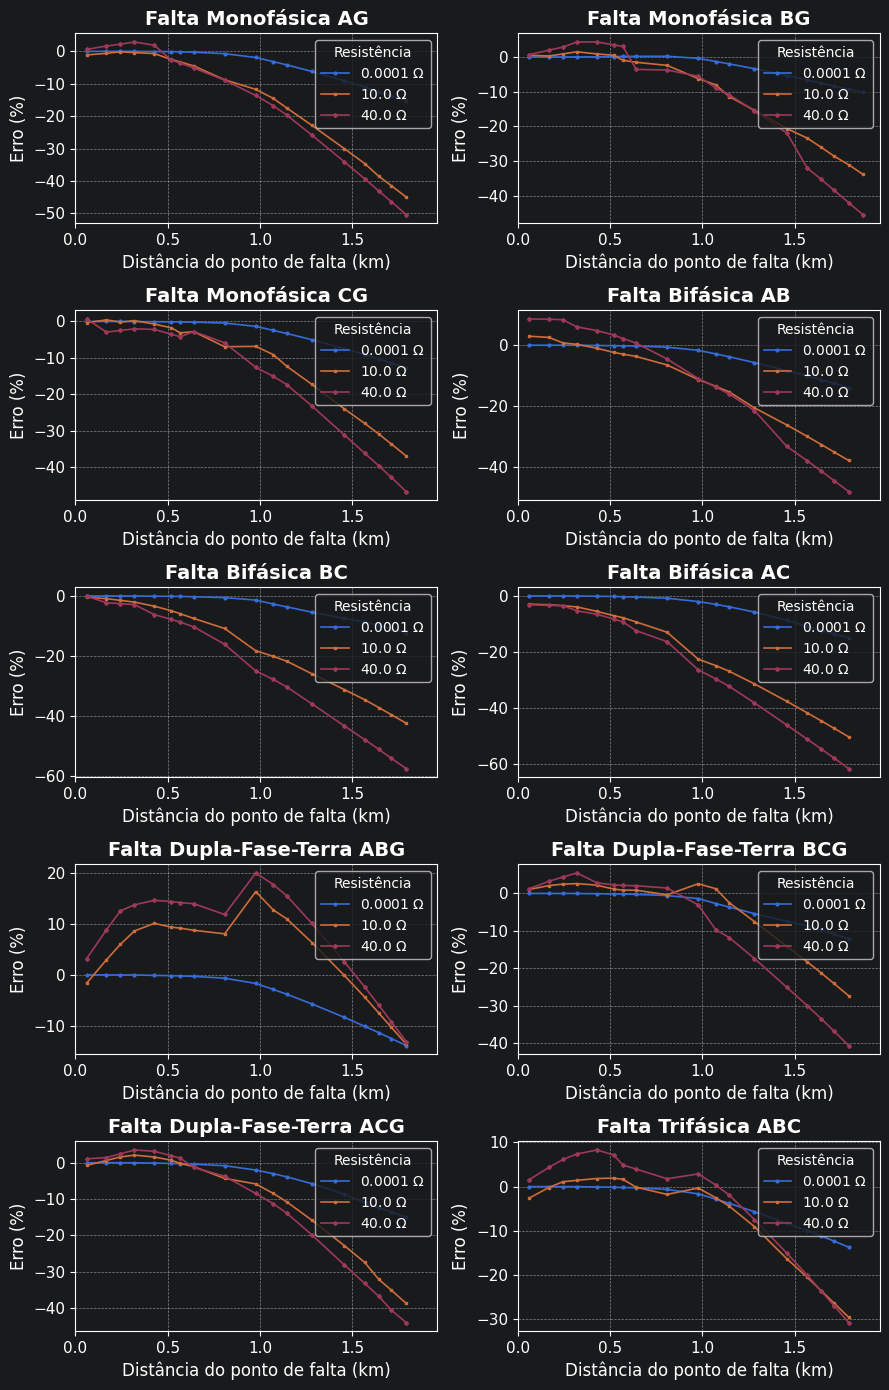

In [5]:
plot_erro(df1, simulador)

## Medida SE, com regulador tap setado

In [6]:
simulador = fault.FaultSimulator(str(DSS_FILE_REG_SET), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.5
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_REG_SET), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df2 = localizador.df.copy()

Aplicando Filtro MI: 100%|██████████| 2001/2001 [00:00<00:00, 7787.40it/s]


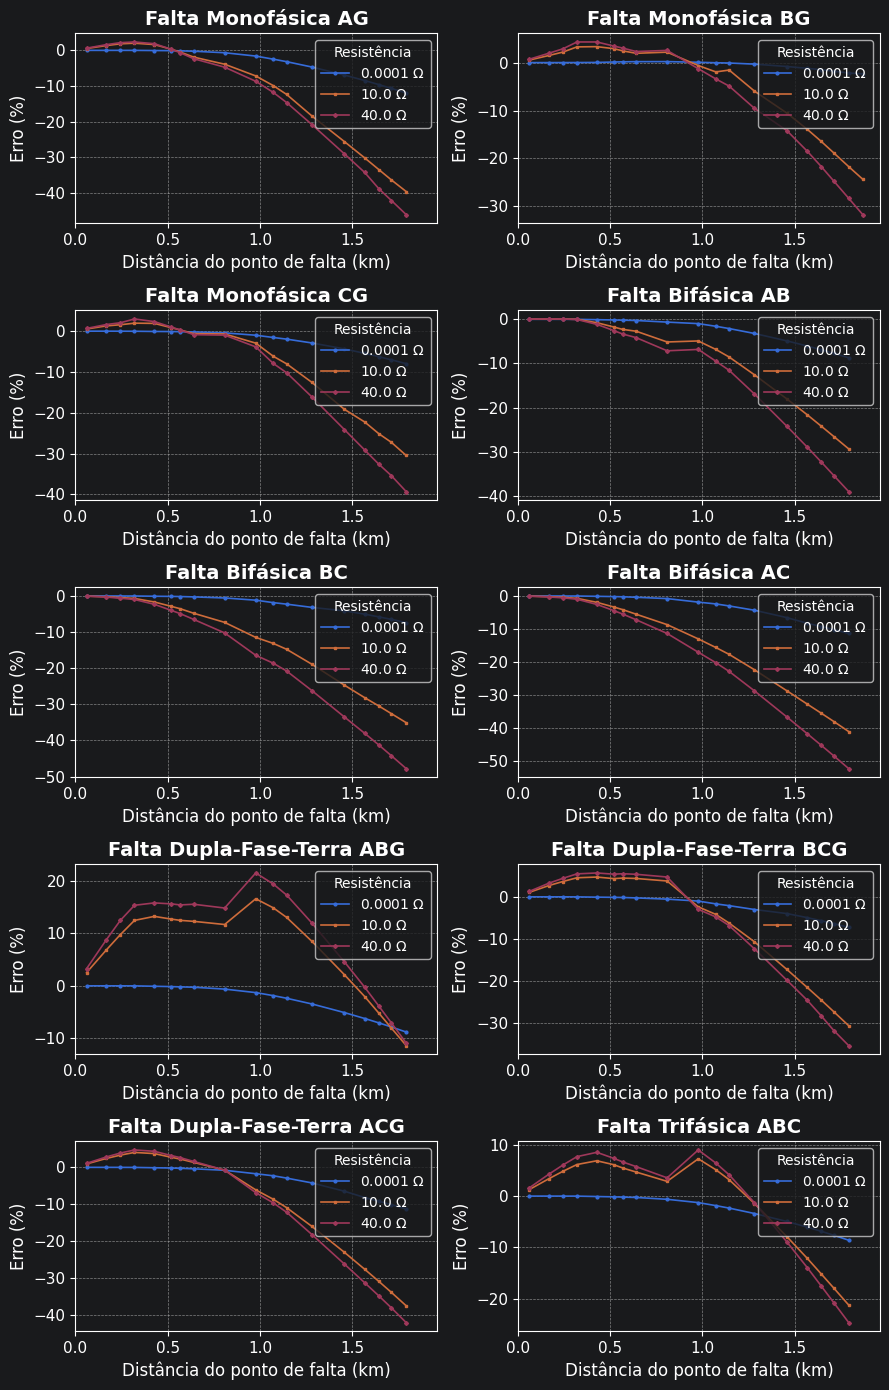

In [7]:
plot_erro(df2, simulador)

## Medida SE, sem regulador

In [8]:
simulador = fault.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.5  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df3 = localizador.df.copy()

Aplicando Filtro MI: 100%|██████████| 2001/2001 [00:00<00:00, 7561.57it/s]


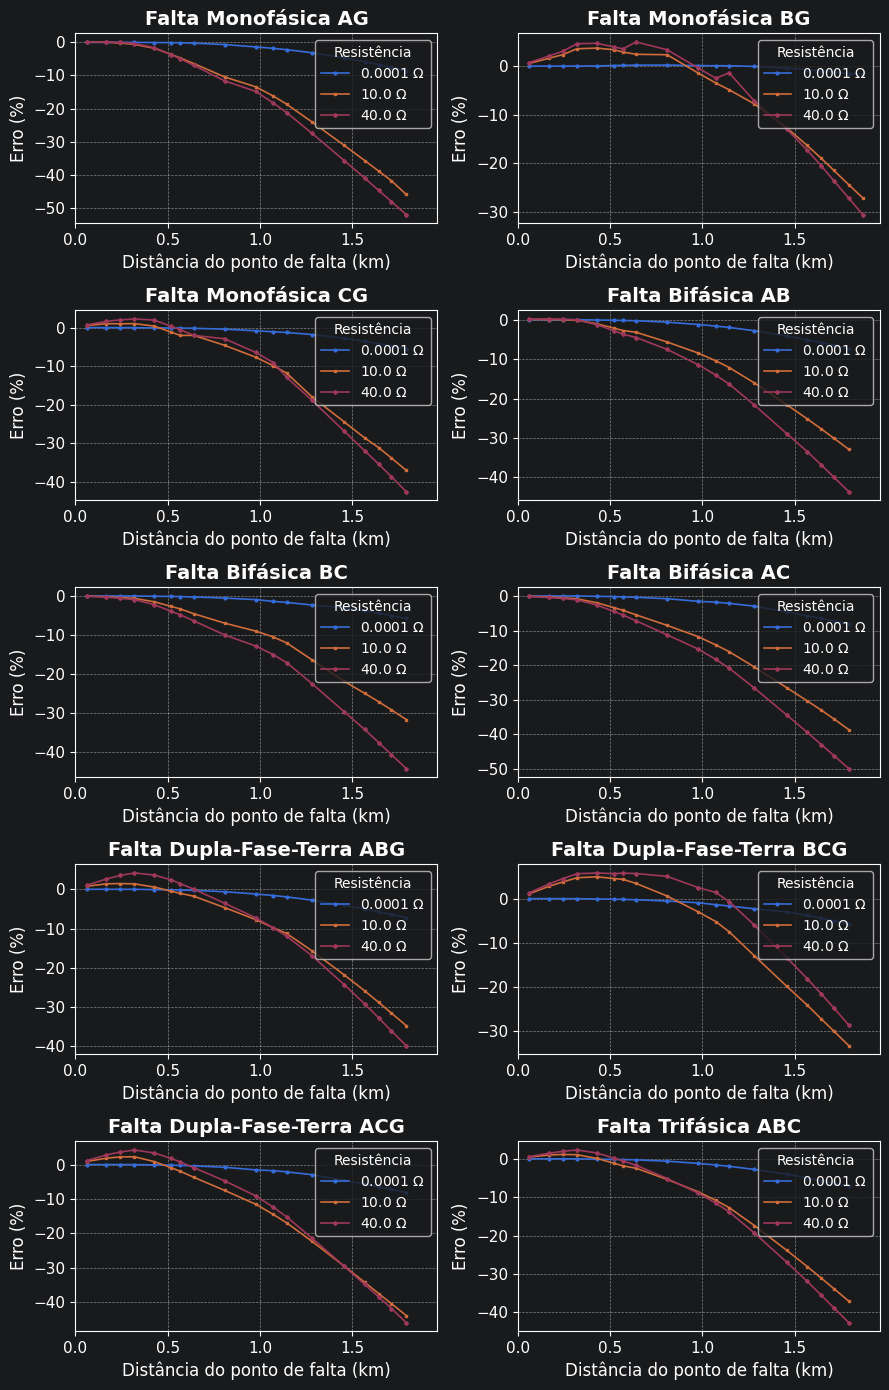

In [9]:
plot_erro(df3, simulador)

## Multiplas medidas, com regulador tap neutro

In [10]:
simulador = fault1.FaultSimulator(str(DSS_FILE_REG_NEUTRAL), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.50
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_REG_NEUTRAL), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df4 = localizador.df.copy()

Localizando Faltas: 100%|██████████| 2001/2001 [15:27<00:00,  2.16it/s]


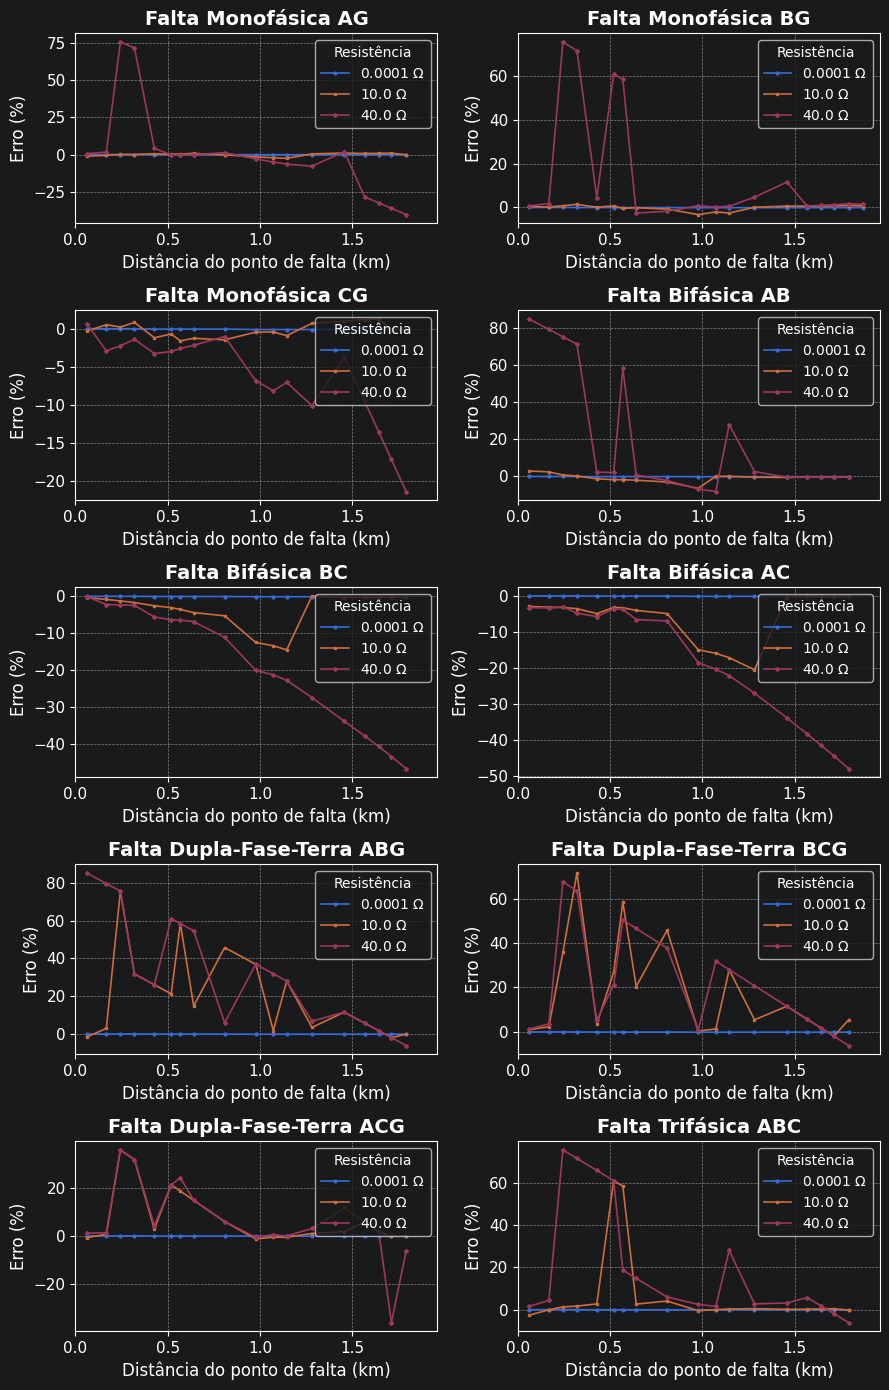

In [11]:
plot_erro(df4, simulador)

## Multiplas medidas, com regulador setado

In [12]:
simulador = fault1.FaultSimulator(str(DSS_FILE_REG_SET), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.50
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_REG_SET), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df5 = localizador.df.copy()


Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 2001/2001 [16:59<00:00,  1.96it/s]


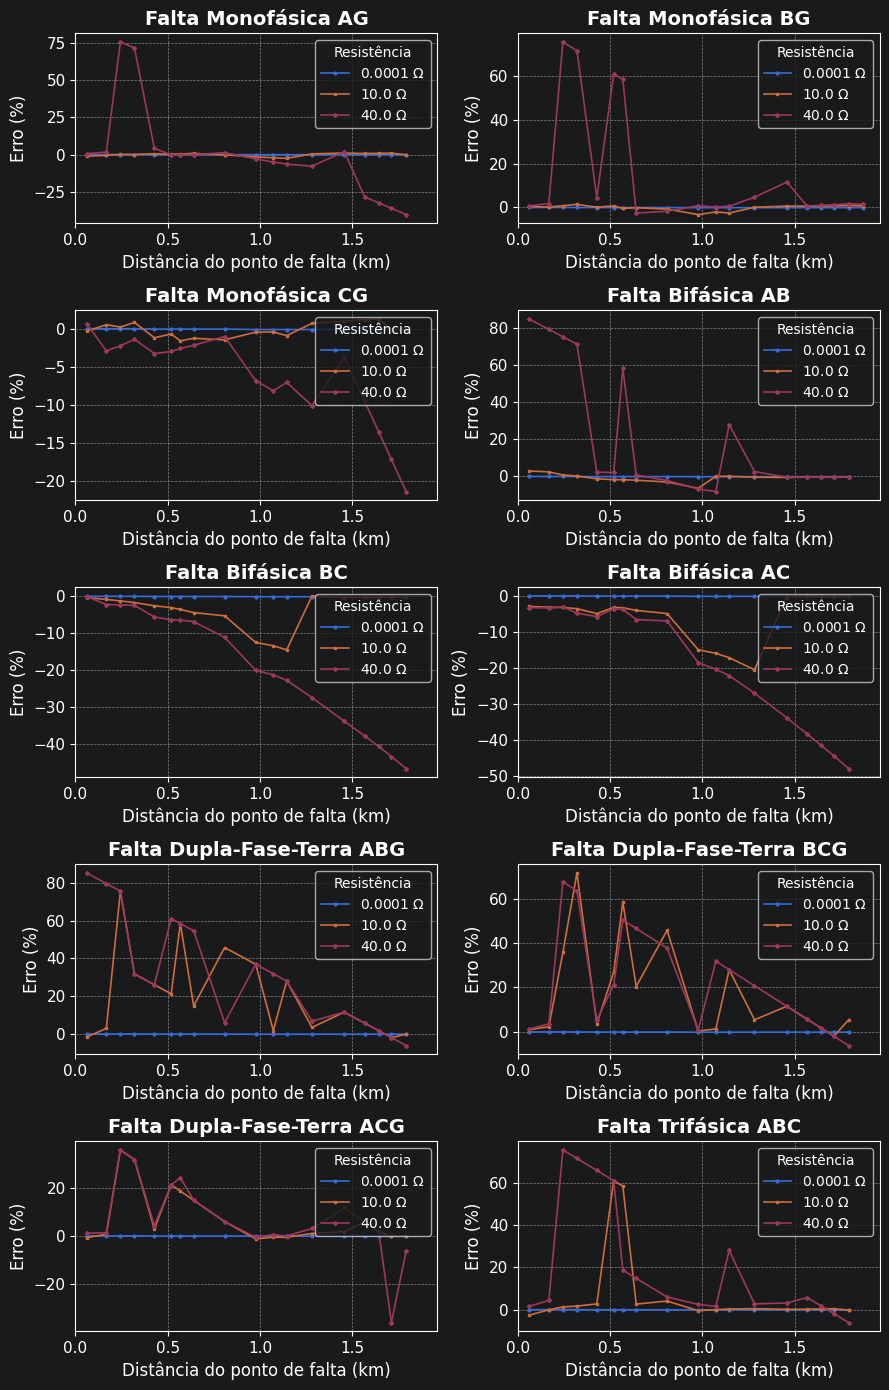

In [13]:
plot_erro(df4, simulador)

## Multiplas medidas, sem regulador

In [14]:
simulador = fault1.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.50  
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001, 10.0, 40.0]

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df6 = localizador.df.copy()


Iniciando a varredura linear de curtos-circuitos...


Localizando Faltas: 100%|██████████| 2001/2001 [13:51<00:00,  2.41it/s]


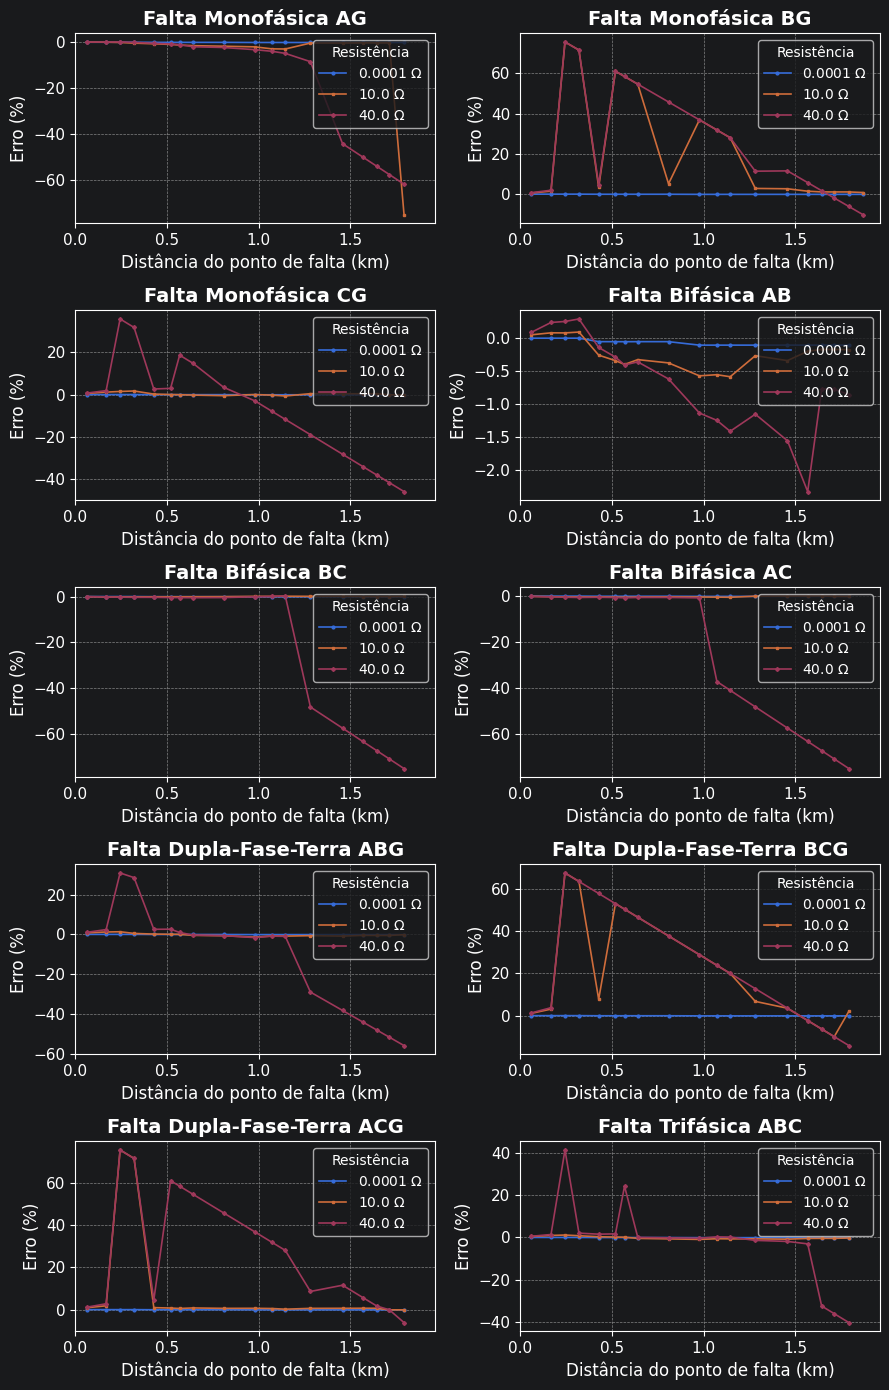

In [15]:
plot_erro(df6, simulador)

## Multiplas medidas, sem regulador, método atualizado

In [16]:
simulador = fault1.FaultSimulator(str(DSS_FILE_NO_REG), origin_bus='150', target_kv=2.40)

# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.50
# passo_distancia_m = 50.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]
resistencias_falta = [0.0001, 10.0, 40.0]

# simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)
simulador.run_simulation(step_pct=passo_distancia, r_list=resistencias_falta)

localizador = locator1_2.FaultLocator(str(DSS_FILE_NO_REG), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()

df7 = localizador.df.copy()

Localizando Faltas: 100%|██████████| 2001/2001 [12:13<00:00,  2.73it/s]


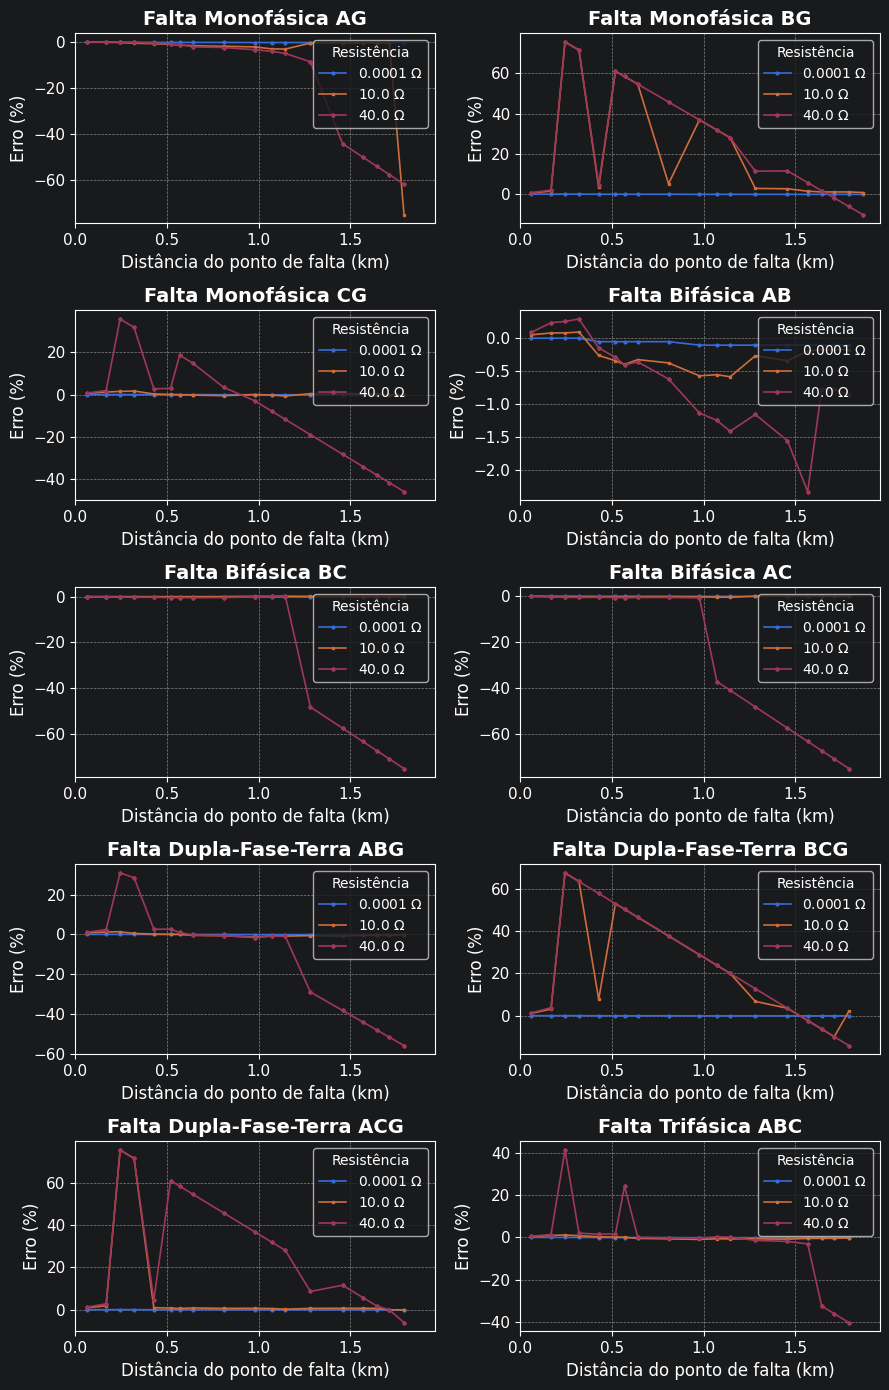

In [17]:
plot_erro(df7, simulador)